In [1]:
# =========================================================
# OLYMPIC ANALYTICS
# DATA CLEANING & FEATURE ENGINEERING
# Für Power BI & Machine Learning
# =========================================================
# ab 24. DATA VISUALIZATION
# OLYMPIC ANALYTICS DASHBOARD WITH PYTHON
# =========================================================

# Projekt:
# Vorbereitung olympischer Daten für:
#
# - Power BI Dashboard
# - Machine Learning
# - Future Prediction
# - Streamlit Deployment
#
# Ziel:
# Professionelle Datenbereinigung,
# Feature Engineering
# und Erstellung sauberer Datensätze.
# =========================================================


In [1]:

# =========================================================
# 1. BIBLIOTHEKEN IMPORTIEREN
# =========================================================

# Datenanalyse
import pandas as pd
import numpy as np

# Warnungen unterdrücken
import warnings
warnings.filterwarnings("ignore")

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


In [16]:
# =========================================================
# 2. DATEN LADEN
# =========================================================

# Olympische Daten laden

df = pd.read_csv(
    "../../01_data/processed/olympics_analysis.csv"
)

print("\nDaten erfolgreich geladen.")


Daten erfolgreich geladen.


In [17]:
# =========================================================
# 3. ERSTE DATENÜBERSICHT
# =========================================================

print("\n=================================================")
print("ERSTE 5 ZEILEN")
print("=================================================\n")

display(df.head())

print("\n=================================================")
print("DATENSTRUKTUR")
print("=================================================\n")

df.info()

print("\n=================================================")
print("DATASET SHAPE")
print("=================================================\n")

print(df.shape)

print("\n=================================================")
print("FEHLENDE WERTE")
print("=================================================\n")

print(df.isnull().sum())


ERSTE 5 ZEILEN



,participations_id,age,height_cm,weight_kg,athlete_id,name,gender,noc,country_name,sport_name,event_name,date,year,medal_type
0,116276,26,179,72,73029,Ian Reay Mackay,M,ZIM,Zimbabwe,Hockey,Hockey Men's Hockey,1964-01-01,1964,No Medal
1,18605,26,175,70,11972,Byron Hamish Black,M,ZIM,Zimbabwe,Tennis,Tennis Men's Doubles,1996-01-01,1996,No Medal
2,18604,26,175,70,11972,Byron Hamish Black,M,ZIM,Zimbabwe,Tennis,Tennis Men's Singles,1996-01-01,1996,No Medal
3,18608,21,167,55,11973,Cara Cavell Black (-Stephens),F,ZIM,Zimbabwe,Tennis,Tennis Women's Singles,2008-01-01,2008,No Medal
4,49657,23,167,67,31141,Brian Dzingai,M,ZIM,Zimbabwe,Athletics,Athletics Men's 200 metres,2004-01-01,2004,No Medal



DATENSTRUKTUR

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209443 entries, 0 to 209442
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   participations_id  209443 non-null  int64 
 1   age                209443 non-null  int64 
 2   height_cm          209443 non-null  int64 
 3   weight_kg          209443 non-null  int64 
 4   athlete_id         209443 non-null  int64 
 5   name               209443 non-null  object
 6   gender             209443 non-null  object
 7   noc                209443 non-null  object
 8   country_name       209443 non-null  object
 9   sport_name         209443 non-null  object
 10  event_name         209443 non-null  object
 11  date               209443 non-null  object
 12  year               209443 non-null  int64 
 13  medal_type         209443 non-null  object
dtypes: int64(6), object(8)
memory usage: 22.4+ MB

DATASET SHAPE

(209443, 14)

FEHLENDE WERTE

particip

In [18]:
# =========================================================
# 4. HEIGHT & WEIGHT BEREINIGEN
# =========================================================

# Fehlende Größe mit Median
# pro Gender und Sport ersetzen

df["height_cm"] = df["height_cm"].fillna(

    df.groupby(
        ["gender", "sport_name"]
    )["height_cm"].transform("median")
)

# Fehlendes Gewicht mit Median
# pro Gender und Sport ersetzen

df["weight_kg"] = df["weight_kg"].fillna(

    df.groupby(
        ["gender", "sport_name"]
    )["weight_kg"].transform("median")
)

print("\nHeight & Weight gruppiert ersetzt.")


Height & Weight gruppiert ersetzt.


In [19]:
# =========================================================
# 5. RESTLICHE FEHLENDE WERTE ERSETZEN
# =========================================================

# Restliche fehlende Größen

df["height_cm"] = df["height_cm"].fillna(

    df["height_cm"].median()
)

# Restliche fehlende Gewichte

df["weight_kg"] = df["weight_kg"].fillna(

    df["weight_kg"].median()
)

print("\nRestliche Height & Weight ersetzt.")


Restliche Height & Weight ersetzt.


In [20]:
# =========================================================
# 6. MEDAILLENWERTE BEREINIGEN
# WICHTIG FÜR MACHINE LEARNING
# =========================================================

# Fehlende Medaillenwerte ersetzen

df["medal_type"] = df["medal_type"].fillna(

    "No Medal"
)

# Zusätzliche Schreibweisen vereinheitlichen

df["medal_type"] = df["medal_type"].replace({

    "keine Medal": "No Medal",
    "No medal": "No Medal",
    "None": "No Medal"
})

print("\nMedaillenwerte bereinigt.")

print("\nMedaillenverteilung:\n")

print(df["medal_type"].value_counts())


Medaillenwerte bereinigt.

Medaillenverteilung:

medal_type
No Medal    176962
Gold         10962
Bronze       10884
Silver       10635
Name: count, dtype: int64


In [21]:
# =========================================================
# 7. LÄNDERDATEN BEREINIGEN
# =========================================================

# UNK + fehlendes Land finden
rows_to_drop = df[

    (df["noc"] == "UNK")

    &

    (df["country_name"].isna())

].index


# Anzahl speichern
deleted_rows = len(rows_to_drop)


# Zeilen löschen
df.drop(

    rows_to_drop,

    inplace=True
)


# Ausgabe
print(
    f"\n{deleted_rows} ungültige Länder-Zeilen wurden entfernt."
)


0 ungültige Länder-Zeilen wurden entfernt.


In [22]:
# =========================================================
# 8. FEHLENDE LÄNDER ERSETZEN
# =========================================================

# ---------------------------------------------
# Romania ergänzen
# ---------------------------------------------

mask = (

    (df["noc"] == "ROT")

    &

    (df["country_name"].isna())
)

# Anzahl speichern
romania_replaced = mask.sum()

# Ersetzen
df.loc[mask, "country_name"] = "Romania"


# ---------------------------------------------
# Tuvalu ergänzen
# ---------------------------------------------

mask = (

    (df["noc"] == "TUV")

    &

    (df["country_name"].isna())
)

# Anzahl speichern
tuvalu_replaced = mask.sum()

# Ersetzen
df.loc[mask, "country_name"] = "Tuvalu"


# ---------------------------------------------
# Gesamtanzahl
# ---------------------------------------------

total_replaced = (
    romania_replaced +
    tuvalu_replaced
)

print(
    f"\n{total_replaced} fehlende Länder wurden ersetzt."
)


0 fehlende Länder wurden ersetzt.


In [23]:
# =========================================================
# 9. LÄNDERNAMEN VEREINHEITLICHEN
# =========================================================

# ---------------------------------------------
# UK -> Great Britain
# ---------------------------------------------

mask = (

    (df["noc"] == "GBR")

    &

    (df["country_name"] == "UK")
)

# Anzahl speichern
standardized_count = mask.sum()

# Vereinheitlichen
df.loc[mask, "country_name"] = "Great Britain"


# ---------------------------------------------
# Ausgabe
# ---------------------------------------------

print(
    f"\n{standardized_count} Ländernamen wurden vereinheitlicht."
)


0 Ländernamen wurden vereinheitlicht.


In [24]:
# =========================================================
# 10. DUPLIKATE PRÜFEN
# =========================================================

print("\n=================================================")
print("DUPLIKATE")
print("=================================================\n")

print(

    "Anzahl Duplikate:",

    df.duplicated().sum()
)

# Optional:
# Duplikate löschen

df.drop_duplicates(inplace=True)

print("\nDuplikate entfernt.")


DUPLIKATE

Anzahl Duplikate: 0

Duplikate entfernt.


In [25]:
# =========================================================
# 11. ALTER BEREINIGEN
# =========================================================

# Alter = 0 prüfen

df_age_zero = df[

    df["age"] == 0
]

print("\nPersonen mit Alter = 0:\n")

display(df_age_zero)

print(

    "\nAnzahl:",

    df_age_zero.shape[0]
)

# Alter = 0 löschen

df.drop(

    df[df["age"] == 0].index,

    inplace=True
)

print("\nUngültige Alterswerte entfernt.")


Personen mit Alter = 0:



,participations_id,age,height_cm,weight_kg,athlete_id,name,gender,noc,country_name,sport_name,event_name,date,year,medal_type



Anzahl: 0

Ungültige Alterswerte entfernt.


In [26]:
# =========================================================
# 12. GEWICHT BEREINIGEN
# =========================================================

# Fehlerhafte Werte prüfen

filtered_df = df.loc[

    df["weight_kg"] == 7
]

print("\nPersonen mit 7 kg Gewicht:\n")

display(filtered_df)

# Fehler korrigieren

df.loc[

    df["weight_kg"] == 7,

    "weight_kg"

] = 70

print("\nGewichtsfehler korrigiert.")


Personen mit 7 kg Gewicht:



,participations_id,age,height_cm,weight_kg,athlete_id,name,gender,noc,country_name,sport_name,event_name,date,year,medal_type



Gewichtsfehler korrigiert.


In [27]:
# =========================================================
# 13. BMI FEATURE ERSTELLEN
# =========================================================

# BMI berechnen

df["bmi"] = (

    df["weight_kg"]

    /

    ((df["height_cm"] / 100) ** 2)
)

print("\nBMI erfolgreich berechnet.")


BMI erfolgreich berechnet.


In [28]:
# =========================================================
# 14. ZIELVARIABLE FÜR ML ERSTELLEN
# WICHTIGER BLOCK
# =========================================================

# Medal Winner:
#
# 1 = Medaille gewonnen
# 0 = Keine Medaille

df["medal_win"] = df["medal_type"].apply(

    lambda x: 0 if x == "No Medal" else 1
)

print("\nmedal_win erfolgreich erstellt.")

print("\nVerteilung:\n")

print(df["medal_win"].value_counts())


medal_win erfolgreich erstellt.

Verteilung:

medal_win
0    176962
1     32481
Name: count, dtype: int64


In [29]:
# =========================================================
# 15. FINALEN DATENSATZ PRÜFEN
# =========================================================

print("\n=================================================")
print("FINAL FEHLENDE WERTE")
print("=================================================\n")

print(df.isnull().sum())


FINAL FEHLENDE WERTE

participations_id    0
age                  0
height_cm            0
weight_kg            0
athlete_id           0
name                 0
gender               0
noc                  0
country_name         0
sport_name           0
event_name           0
date                 0
year                 0
medal_type           0
bmi                  0
medal_win            0
dtype: int64


In [30]:
# =========================================================
# 16. POWER BI DATASET ERSTELLEN
# =========================================================

df_bi = df[[

    "participations_id",
    "athlete_id",
    "age",
    "height_cm",
    "weight_kg",
    "bmi",
    "gender",
    "noc",
    "country_name",
    "sport_name",
    "year",
    "medal_type",
    "event_name"
]]

print("\nPower BI Dataset erstellt.")


Power BI Dataset erstellt.


In [31]:
# =========================================================
# 17. POWER BI DATASET EXPORTIEREN
# =========================================================

df_bi.to_csv(

    "../../01_data/processed/olympics_BI_cleaned.csv",

    index=False
)

print("\nPower BI CSV gespeichert.")


Power BI CSV gespeichert.


In [32]:
# =========================================================
# 18. MACHINE LEARNING DATASET ERSTELLEN
# =========================================================

df_ml = df[[

    "age",
    "height_cm",
    "weight_kg",
    "bmi",
    "gender",
    "sport_name",
    "year",
    "country_name",
    "medal_type",
    "medal_win"
]]

print("\nMachine Learning Dataset erstellt.")


Machine Learning Dataset erstellt.


In [33]:
# =========================================================
# 19. MACHINE LEARNING DATASET EXPORTIEREN
# =========================================================

df_ml.to_csv(

    "../../01_data/processed/olympics_ML_cleaned.csv",

    index=False
)

print("\nML CSV gespeichert.")


ML CSV gespeichert.


In [34]:
# =========================================================
# 20. DESKRIPTIVE STATISTIK
# =========================================================

print("\n=================================================")
print("DESKRIPTIVE STATISTIK")
print("=================================================\n")

display(

    df_bi.describe()
)


DESKRIPTIVE STATISTIK



,participations_id,athlete_id,age,height_cm,weight_kg,bmi,year
count,209443.000000,209443.000000,209443.000000,209443.000000,209443.000000,209443.000000,209443.000000
mean,108444.019242,68037.417173,23.860998,175.638431,70.857756,22.784505,1979.396762
std,62525.411445,39117.616076,5.746575,10.336987,13.820940,2.802314,28.566725
min,1.000000,1.000000,11.000000,127.000000,25.000000,8.360954,1904.000000
25%,54382.500000,34139.000000,20.000000,168.000000,62.000000,21.132713,1960.000000
50%,108395.000000,68314.000000,23.000000,176.000000,71.000000,22.598140,1988.000000
75%,162549.500000,101870.500000,26.000000,182.000000,78.000000,24.158818,2004.000000
max,216784.000000,135568.000000,97.000000,226.000000,214.000000,63.901580,2016.000000


In [35]:
# =========================================================
# 21. MEDAILLENVERTEILUNG
# =========================================================

print("\n=================================================")
print("MEDAILLENVERTEILUNG")
print("=================================================\n")

display(

    df_bi["medal_type"].value_counts()
)


MEDAILLENVERTEILUNG



medal_type
No Medal    176962
Gold         10962
Bronze       10884
Silver       10635
Name: count, dtype: int64

In [36]:
# =========================================================
# 22. DURCHSCHNITTSALTER NACH MEDAILLE
# =========================================================

print("\n=================================================")
print("DURCHSCHNITTSALTER")
print("=================================================\n")

print(

    df_bi.groupby(
        "medal_type"
    )["age"].mean()
)


DURCHSCHNITTSALTER

medal_type
Bronze      23.868431
Gold        23.879766
No Medal    23.855743
Silver      23.921486
Name: age, dtype: float64


In [37]:
# =========================================================
# 23. PROJEKT ABSCHLUSS
# =========================================================

print("\n=================================================")
print("DATA CLEANING ABGESCHLOSSEN")
print("=================================================\n")

print("Dateien erstellt:")

print("- olympics_BI_cleaned.csv")

print("- olympics_ML_cleaned.csv")


DATA CLEANING ABGESCHLOSSEN

Dateien erstellt:
- olympics_BI_cleaned.csv
- olympics_ML_cleaned.csv


In [38]:
# =========================================================
# 24. DATA VISUALIZATION
# OLYMPIC ANALYTICS DASHBOARD WITH PYTHON
# =========================================================

# Ziel:
#
# Visualisierung der wichtigsten olympischen Analysen
# mit Python.
#
# Technologien:
# - matplotlib
# - seaborn
#
# Diese Visualisierungen basieren auf:
# - SQL Analytics
# - Power BI Dashboard
# - Machine Learning Daten
#
# =========================================================

In [39]:
# =========================================================
# 25. VISUALISIERUNGS-BIBLIOTHEKEN IMPORTIEREN
# =========================================================

# matplotlib für Diagramme
import matplotlib.pyplot as plt

# seaborn für professionelle Visualisierungen
import seaborn as sns

# Professionellen Stil aktivieren
sns.set_style("whitegrid")

print("\nVisualisierungsbibliotheken erfolgreich geladen.")


Visualisierungsbibliotheken erfolgreich geladen.


In [40]:
# =========================================================
# VISUALISIERUNGS-EINSTELLUNGEN
# Einheitliche Größe für ALLE Diagramme
# 
# =========================================================

# Einheitliche Diagrammgröße
FIG_WIDTH = 14
FIG_HEIGHT = 7

# Einheitliche Schriftgrößen
TITLE_SIZE = 18
LABEL_SIZE = 13

# Stil
sns.set_style("whitegrid")

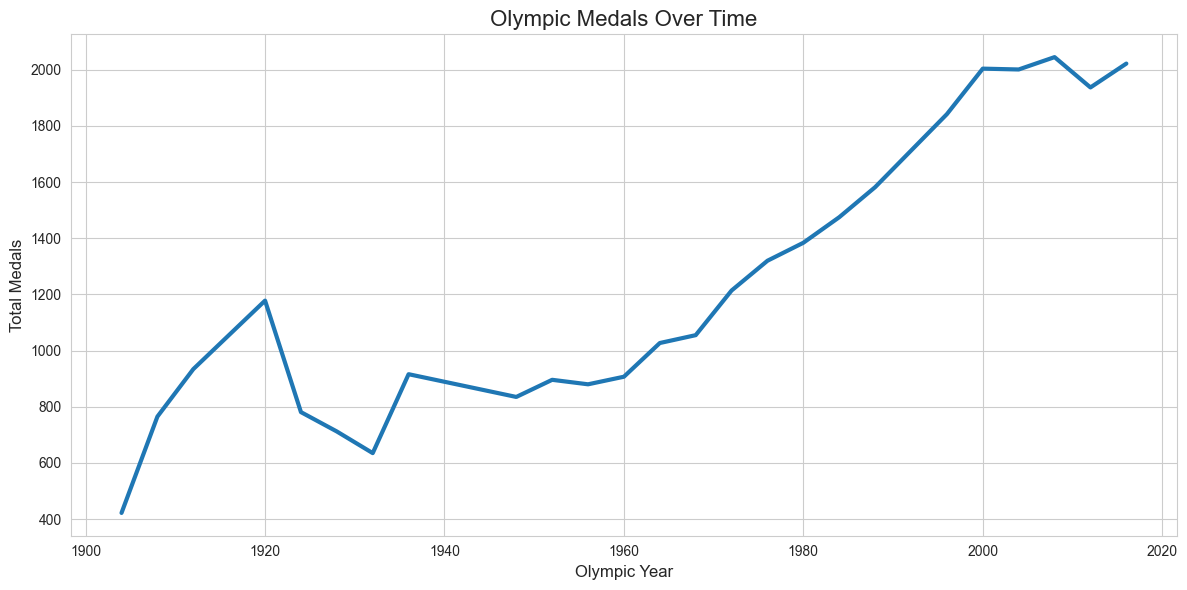

In [41]:
# =========================================================
# PAGE 1 — OLYMPIC OVERVIEW DASHBOARD
# =========================================================

# =========================================================
# 1. MEDALS OVER TIME
# Line Chart
# Olympische Entwicklung über Zeit
# =========================================================

# Nur Medaillengewinner filtern

medals_over_time = (

    df[df["medal_win"] == 1]

    .groupby("year")

    .size()
)

# Diagramm erstellen

plt.figure(figsize=(12,6))

plt.plot(

    medals_over_time.index,

    medals_over_time.values,

    linewidth=3
)

# Titel und Achsen

plt.title(

    "Olympic Medals Over Time",
    fontsize=16
)

plt.xlabel(

    "Olympic Year",
    fontsize=12
)

plt.ylabel(

    "Total Medals",
    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()


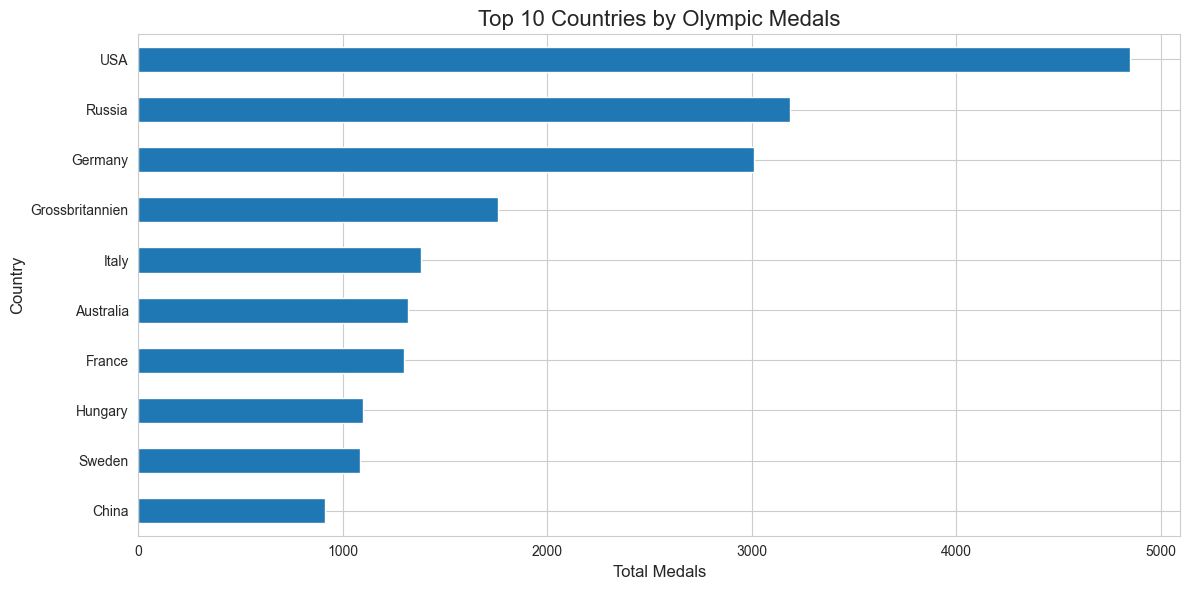

In [42]:
# =========================================================
# 2. TOP 10 COUNTRIES
# Horizontal Bar Chart
# Erfolgreichste Länder
# =========================================================

# Top Länder berechnen

top_countries = (

    df[df["medal_win"] == 1]

    .groupby("country_name")

    .size()

    .sort_values(ascending=True)

    .tail(10)
)

# Diagramm erstellen

plt.figure(figsize=(12,6))

top_countries.plot(

    kind="barh"
)

# Titel

plt.title(

    "Top 10 Countries by Olympic Medals",
    fontsize=16
)

plt.xlabel(

    "Total Medals",
    fontsize=12
)

plt.ylabel(

    "Country",
    fontsize=12
)

plt.tight_layout()

plt.show()

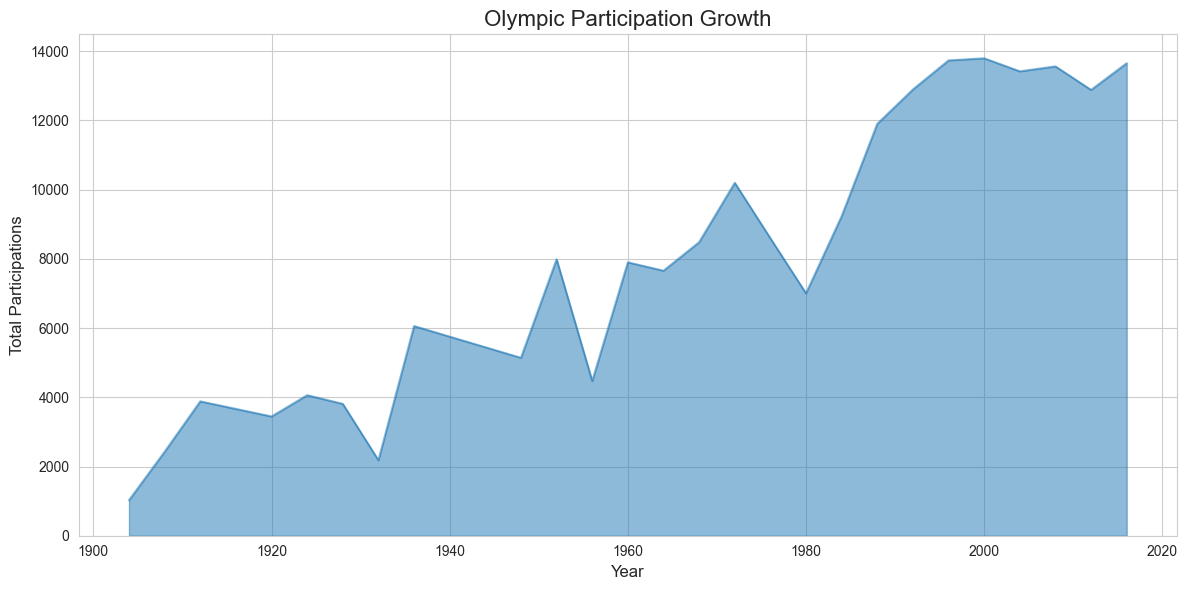

In [43]:
# =========================================================
# 3. PARTICIPATION GROWTH
# Area Chart
# Wachstum der Olympischen Spiele
# =========================================================

participation_growth = (

    df.groupby("year")

    .size()
)

plt.figure(figsize=(12,6))

participation_growth.plot(

    kind="area",

    alpha=0.5
)

plt.title(

    "Olympic Participation Growth",
    fontsize=16
)

plt.xlabel(

    "Year",
    fontsize=12
)

plt.ylabel(

    "Total Participations",
    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()

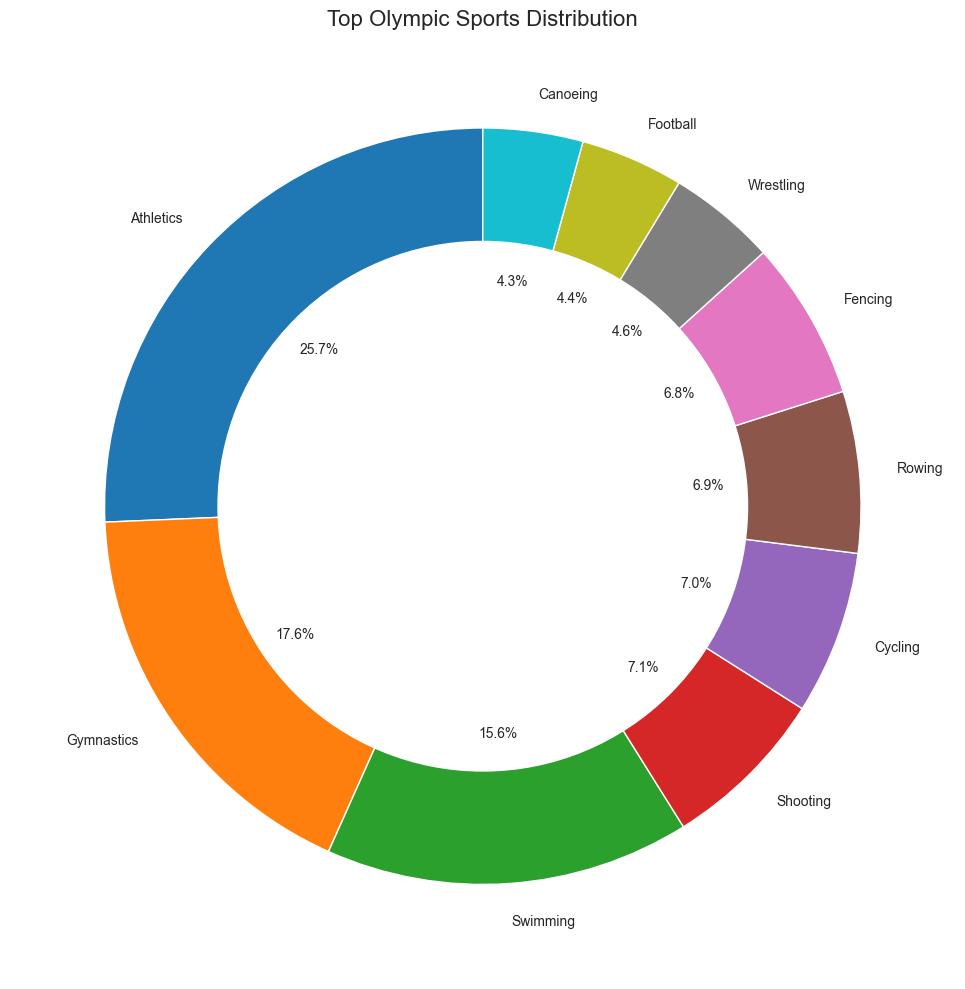

In [44]:
# =========================================================
# 4. SPORTS DISTRIBUTION
# Donut Chart
# Beliebteste Sportarten
# =========================================================

sports_distribution = (

    df["sport_name"]

    .value_counts()

    .head(10)
)

plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(

    sports_distribution,

    labels=sports_distribution.index,

    autopct="%1.1f%%",

    startangle=90
)

# Donut Effekt

centre_circle = plt.Circle(

    (0,0),

    0.70,

    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title(

    "Top Olympic Sports Distribution",
    fontsize=16
)

plt.tight_layout()

plt.show()

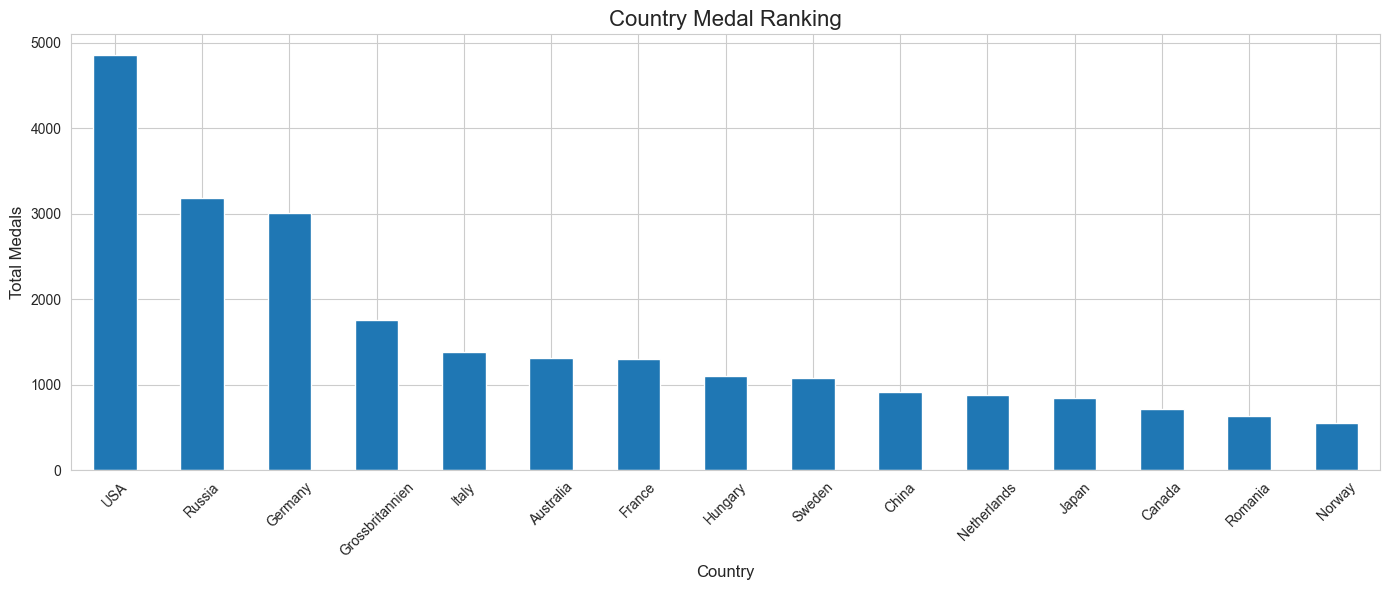

In [45]:
# =========================================================
# PAGE 2 — COUNTRY PERFORMANCE ANALYSIS
# =========================================================

# =========================================================
# 5. COUNTRY MEDAL RANKING
# Bar Chart
# =========================================================

country_medal_ranking = (

    df[df["medal_win"] == 1]

    .groupby("country_name")

    .size()

    .sort_values(ascending=False)

    .head(15)
)

plt.figure(figsize=(14,6))

country_medal_ranking.plot(

    kind="bar"
)

plt.title(

    "Country Medal Ranking",
    fontsize=16
)

plt.xlabel(

    "Country",
    fontsize=12
)

plt.ylabel(

    "Total Medals",
    fontsize=12
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

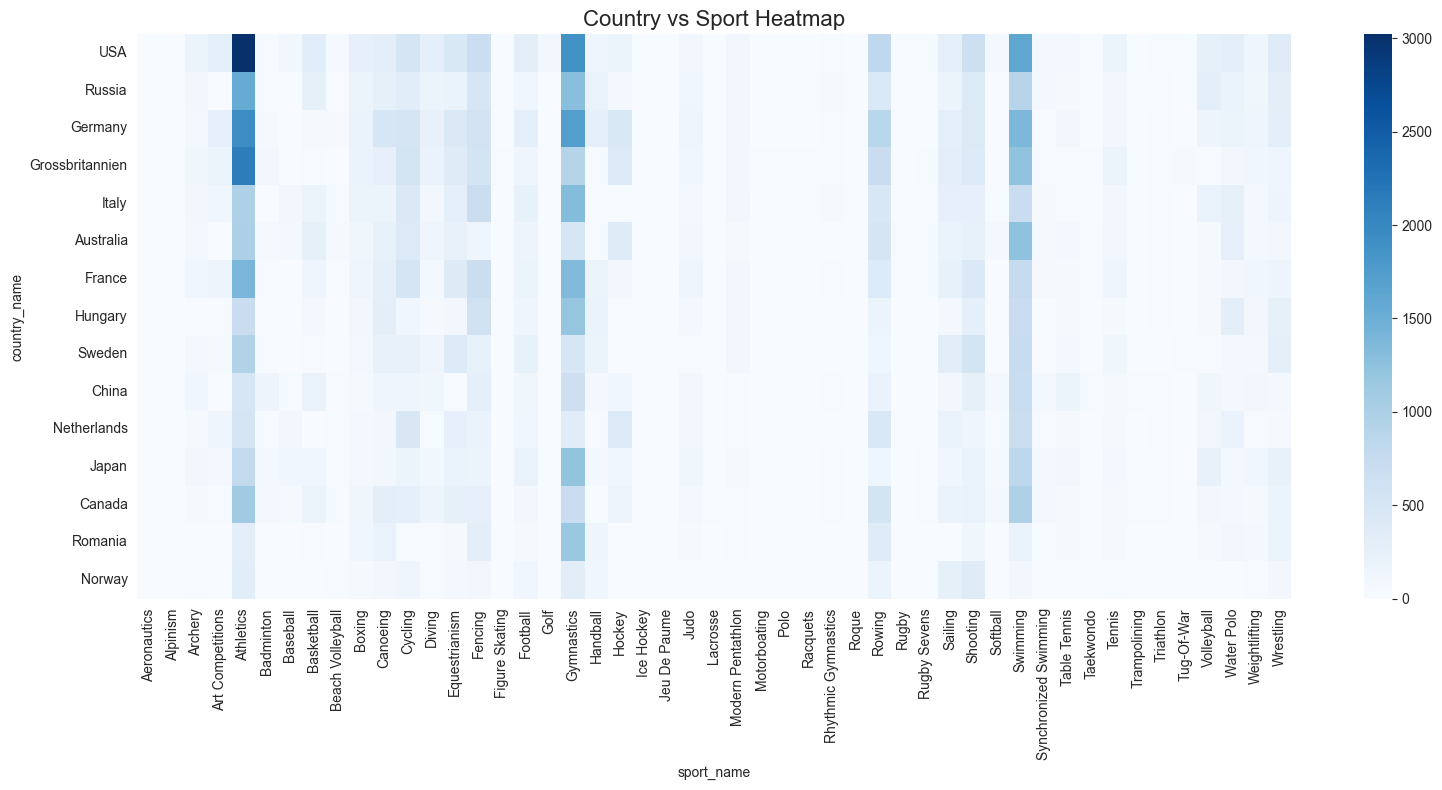

In [46]:
# =========================================================
# 6. COUNTRY VS SPORT HEATMAP
# Matrix Visualisierung
# =========================================================

country_sport = pd.crosstab(

    df["country_name"],

    df["sport_name"]
)

# Top Länder auswählen

top15 = country_medal_ranking.index

country_sport = country_sport.loc[top15]

# Heatmap erstellen

plt.figure(figsize=(16,8))

sns.heatmap(

    country_sport,

    cmap="Blues"
)

plt.title(

    "Country vs Sport Heatmap",
    fontsize=16
)

plt.tight_layout()

plt.show()

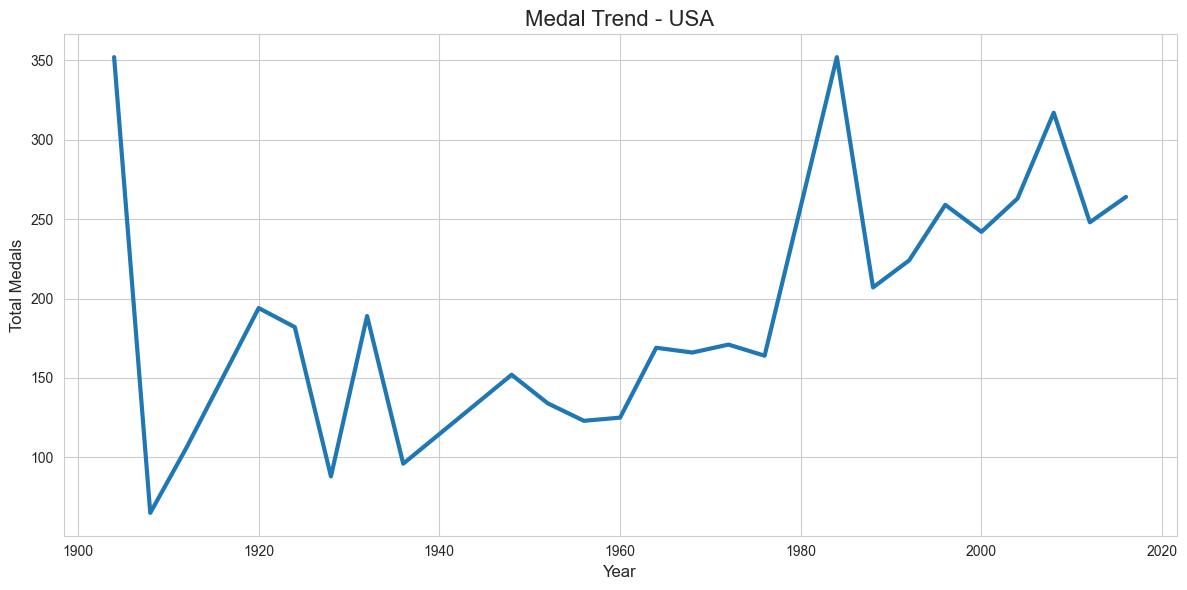

In [47]:
# =========================================================
# 7. MEDAL TREND BY COUNTRY
# Line Chart
# =========================================================

# Beispiel: USA analysieren

selected_country = "USA"

country_trend = (

    df[

        (df["country_name"] == selected_country)

        &

        (df["medal_win"] == 1)
    ]

    .groupby("year")

    .size()
)

plt.figure(figsize=(12,6))

plt.plot(

    country_trend.index,

    country_trend.values,

    linewidth=3
)

plt.title(

    f"Medal Trend - {selected_country}",
    fontsize=16
)

plt.xlabel(

    "Year",
    fontsize=12
)

plt.ylabel(

    "Total Medals",
    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [48]:
# =========================================================
# 8. WORLD MAP
# Sehr professionell
# =========================================================

import plotly.express as px

# Daten vorbereiten

world_map = (

    df.groupby("country_name")

    .agg({

        "participations_id": "count",

        "medal_win": "sum"

    })

    .reset_index()
)

# Spalten umbenennen

world_map.columns = [

    "country_name",

    "total_participations",

    "total_medals"
]

# Map erstellen

fig = px.choropleth(

    world_map,

    locations="country_name",

    locationmode="country names",

    color="total_medals",

    hover_name="country_name",

    hover_data=[

        "total_participations",

        "total_medals"
    ],

    color_continuous_scale="Blues",

    title="Olympic World Map"
)

fig.show()

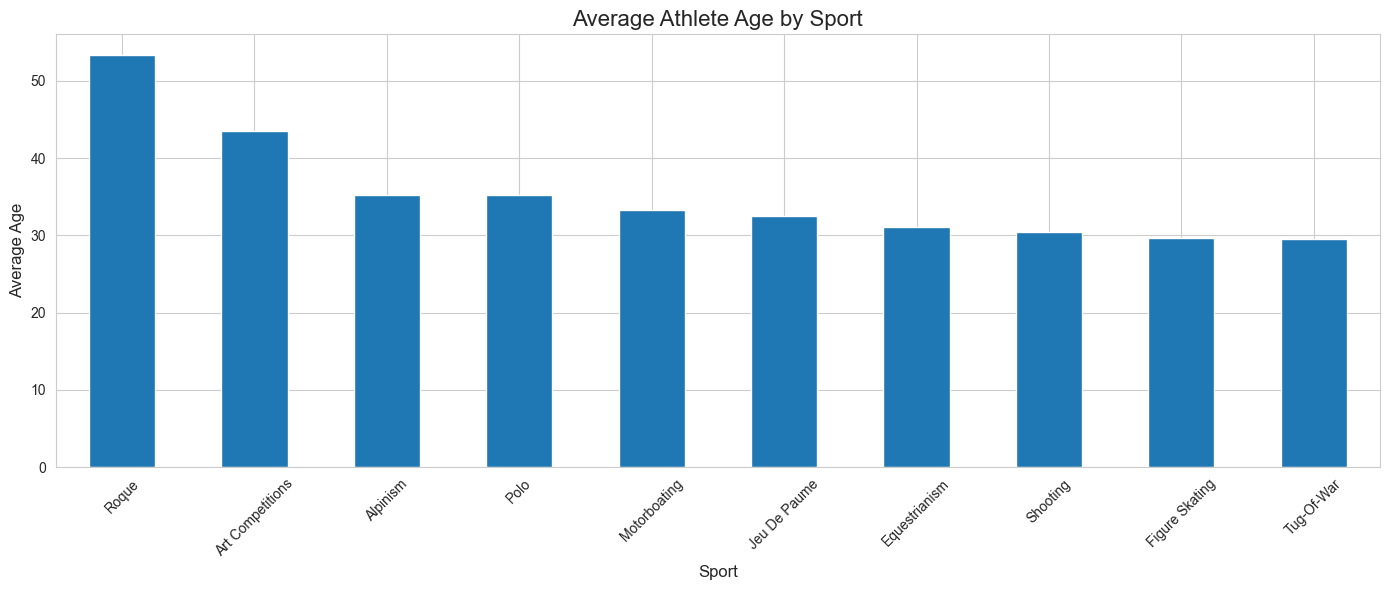

In [49]:
# =========================================================
# PAGE 3 — ATHLETE PERFORMANCE ANALYSIS
# =========================================================

# =========================================================
# 9. AVERAGE AGE BY SPORT
# Bar Chart
# =========================================================

avg_age_sport = (

    df.groupby("sport_name")["age"]

    .mean()

    .sort_values(ascending=False)

    .head(10)
)

plt.figure(figsize=(14,6))

avg_age_sport.plot(

    kind="bar"
)

plt.title(

    "Average Athlete Age by Sport",
    fontsize=16
)

plt.xlabel(

    "Sport",
    fontsize=12
)

plt.ylabel(

    "Average Age",
    fontsize=12
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

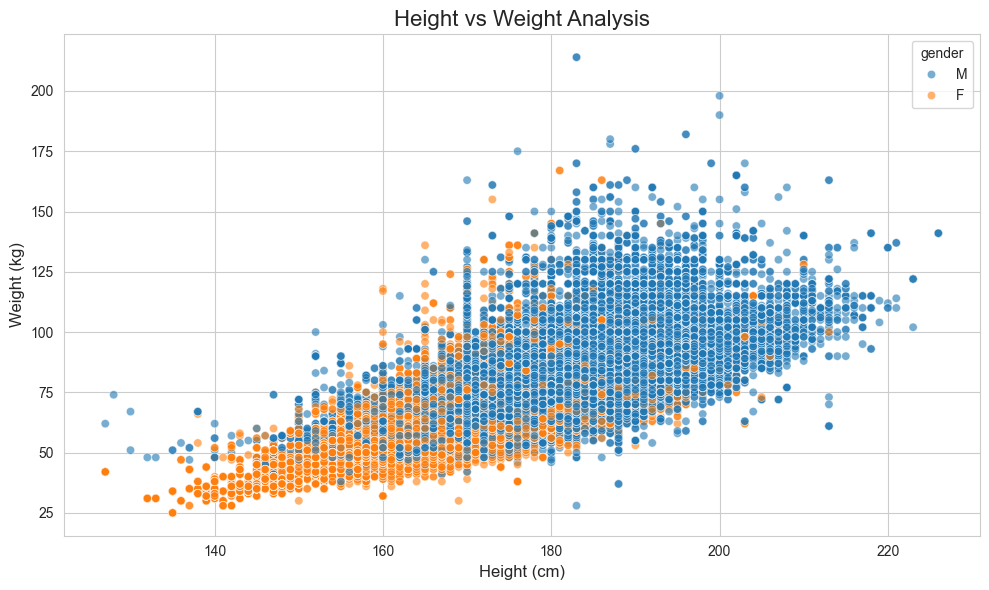

In [50]:
# =========================================================
# 10. HEIGHT VS WEIGHT ANALYSIS
# Scatter Plot
# =========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=df,

    x="height_cm",

    y="weight_kg",

    hue="gender",

    alpha=0.6
)

plt.title(

    "Height vs Weight Analysis",
    fontsize=16
)

plt.xlabel(

    "Height (cm)",
    fontsize=12
)

plt.ylabel(

    "Weight (kg)",
    fontsize=12
)

plt.tight_layout()

plt.show()

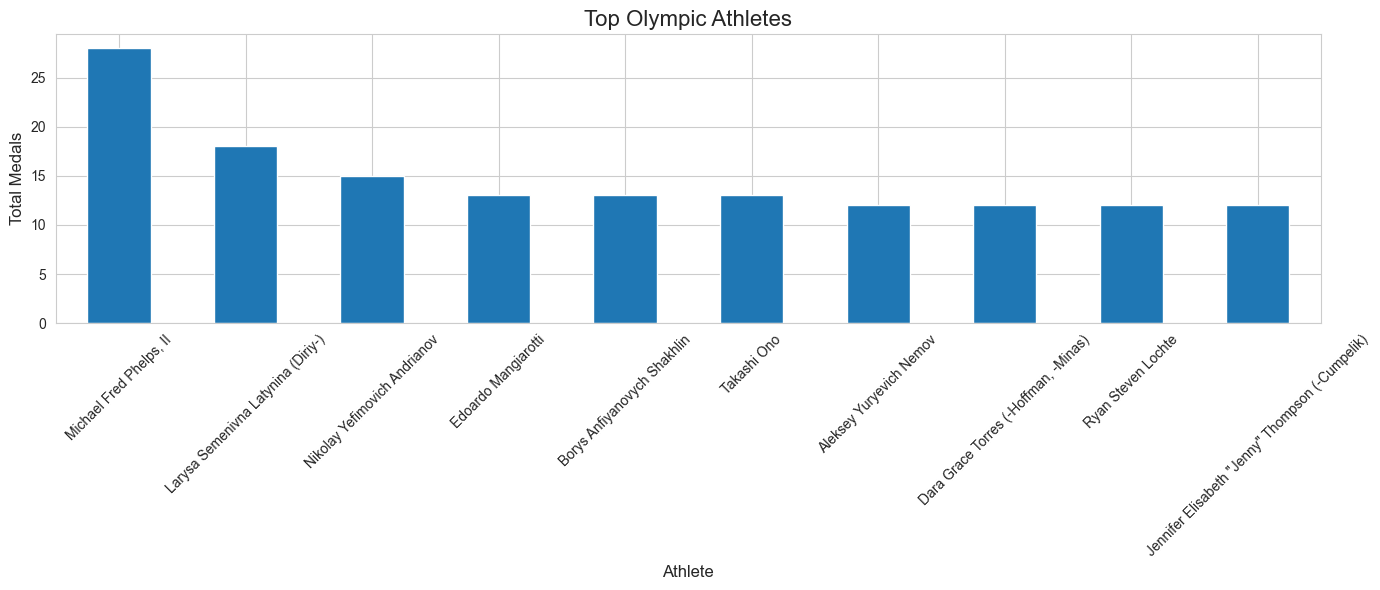

In [51]:
# =========================================================
# 11. TOP ATHLETES
# Bar Chart
# =========================================================

top_athletes = (

    df[df["medal_win"] == 1]

    .groupby("name")

    .size()

    .sort_values(ascending=False)

    .head(10)
)

plt.figure(figsize=(14,6))

top_athletes.plot(

    kind="bar"
)

plt.title(

    "Top Olympic Athletes",
    fontsize=16
)

plt.xlabel(

    "Athlete",
    fontsize=12
)

plt.ylabel(

    "Total Medals",
    fontsize=12
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

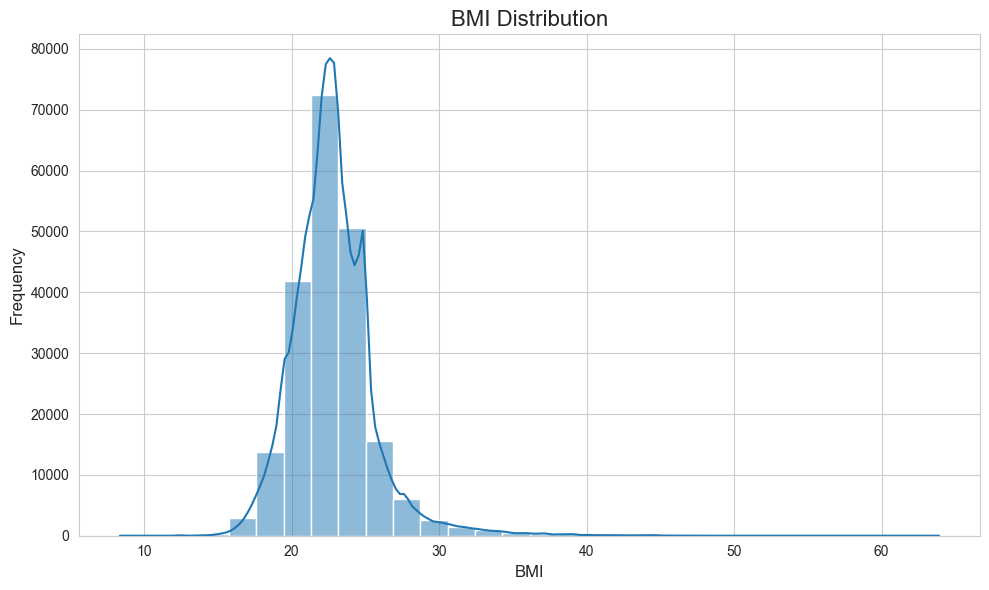

In [52]:
# =========================================================
# 12. BMI DISTRIBUTION
# Histogram
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(

    df["bmi"],

    bins=30,

    kde=True
)

plt.title(

    "BMI Distribution",
    fontsize=16
)

plt.xlabel(

    "BMI",
    fontsize=12
)

plt.ylabel(

    "Frequency",
    fontsize=12
)

plt.tight_layout()

plt.show()

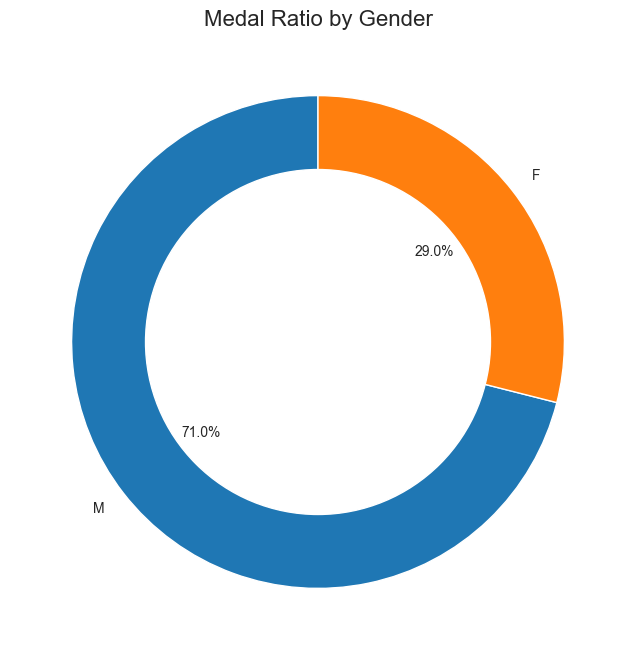

In [53]:
# =========================================================
# PAGE 4 — GENDER & DIVERSITY ANALYSIS
# =========================================================

# =========================================================
# 13. MEDAL RATIO BY GENDER
# Donut Chart
# =========================================================

gender_medals = (

    df[df["medal_win"] == 1]["gender"]

    .value_counts()
)

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(

    gender_medals,

    labels=gender_medals.index,

    autopct="%1.1f%%",

    startangle=90
)

# Donut Effekt

centre_circle = plt.Circle(

    (0,0),

    0.70,

    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title(

    "Medal Ratio by Gender",
    fontsize=16
)

plt.show()

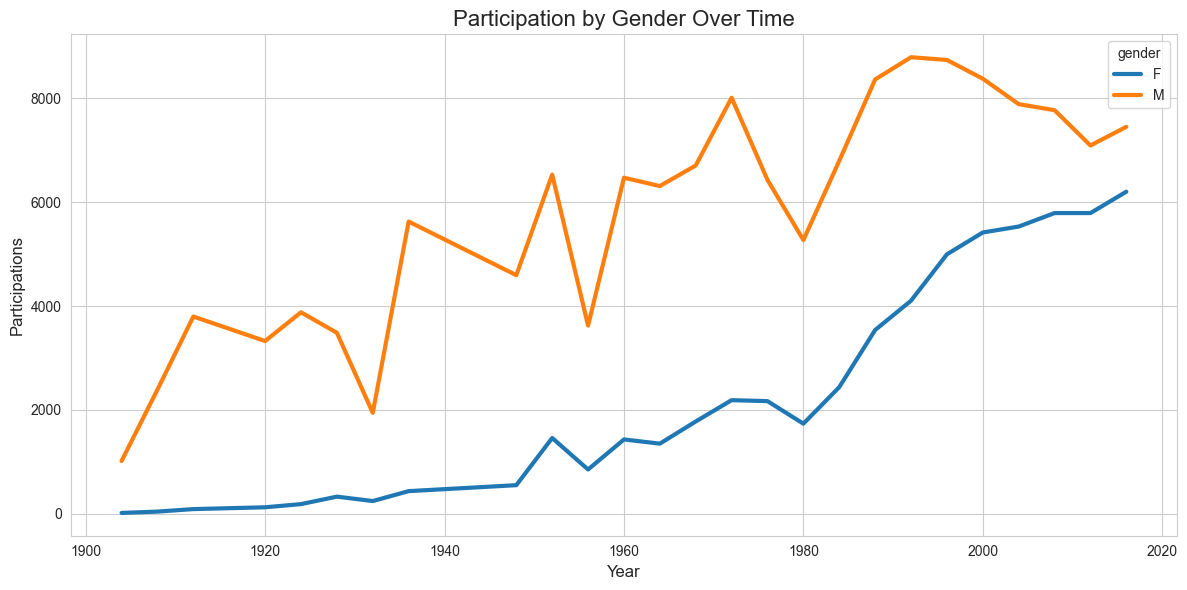

In [54]:
# =========================================================
# 14. PARTICIPATION BY GENDER OVER TIME
# Line Chart
# =========================================================

gender_time = (

    df.groupby(["year","gender"])

    .size()

    .unstack()
)

gender_time.plot(

    figsize=(12,6),

    linewidth=3
)

plt.title(

    "Participation by Gender Over Time",
    fontsize=16
)

plt.xlabel(

    "Year",
    fontsize=12
)

plt.ylabel(

    "Participations",
    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()

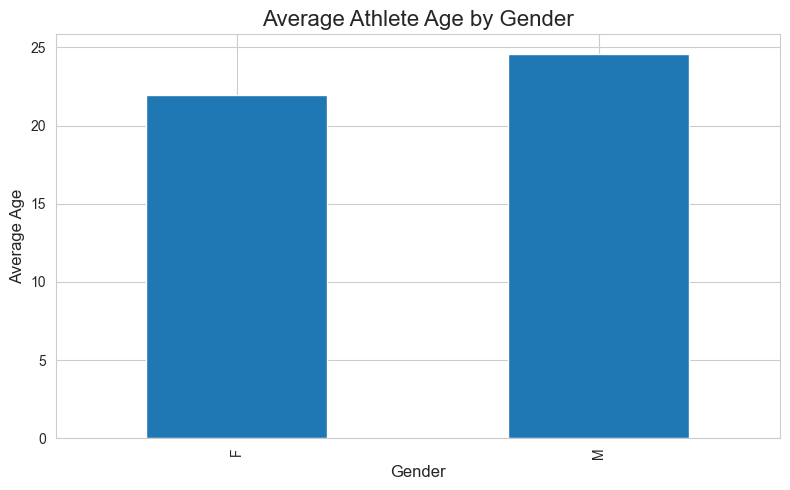

In [56]:
# =========================================================
# 15. AVERAGE AGE BY GENDER
# Clustered Bar Chart
# =========================================================

avg_age_gender = (

    df.groupby("gender")["age"]

    .mean()
)

plt.figure(figsize=(8,5))

avg_age_gender.plot(

    kind="bar"
)

plt.title(

    "Average Athlete Age by Gender",
    fontsize=16
)

plt.xlabel(

    "Gender",
    fontsize=12
)

plt.ylabel(

    "Average Age",
    fontsize=12
)

plt.tight_layout()

plt.show()

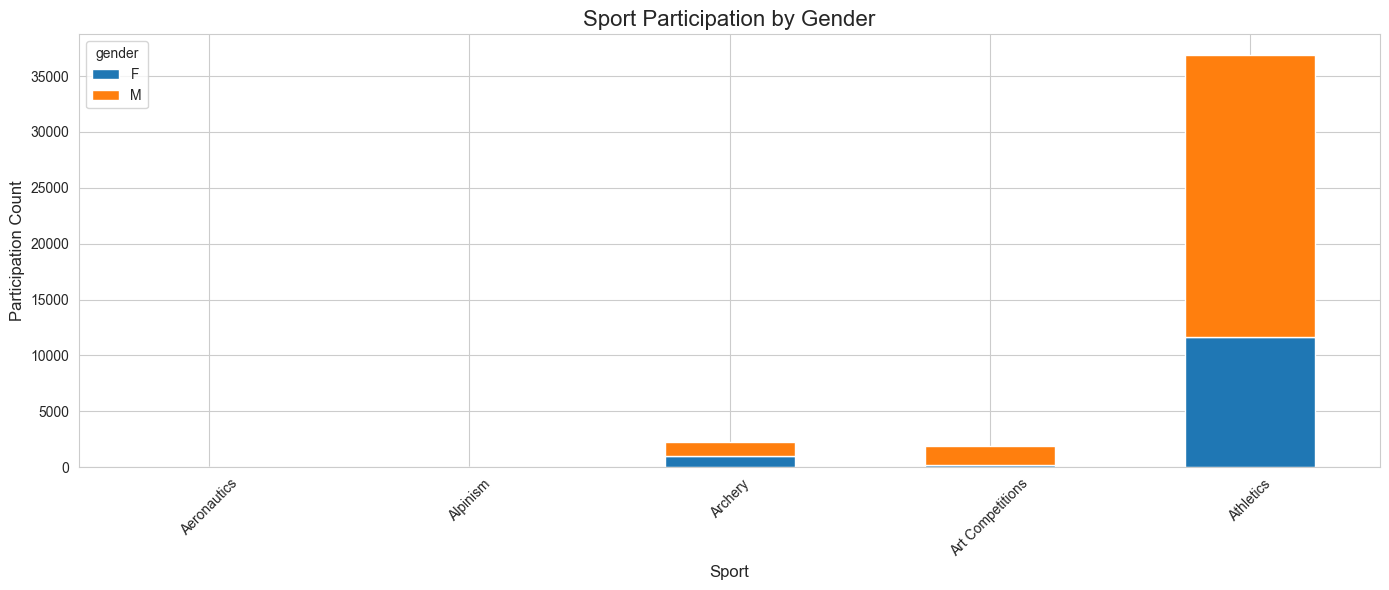

In [55]:
# =========================================================
# 16. SPORT PARTICIPATION BY GENDER
# Stacked Bar Chart
# =========================================================

sport_gender = pd.crosstab(

    df["sport_name"],

    df["gender"]
)

sport_gender.head(5).plot(

    kind="bar",

    stacked=True,

    figsize=(14,6)
)

plt.title(

    "Sport Participation by Gender",
    fontsize=16
)

plt.xlabel(

    "Sport",
    fontsize=12
)

plt.ylabel(

    "Participation Count",
    fontsize=12
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

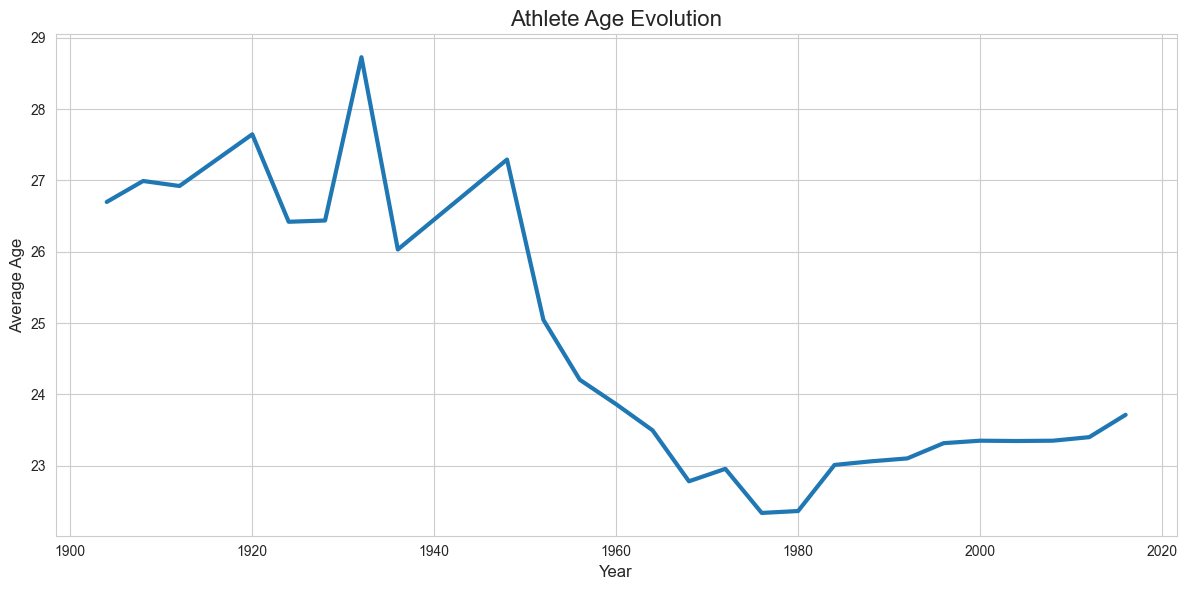

In [57]:
# =========================================================
# PAGE 5 — HISTORICAL TRENDS ANALYSIS
# =========================================================

# =========================================================
# 17. ATHLETE AGE EVOLUTION
# Line Chart
# =========================================================

age_evolution = (

    df.groupby("year")["age"]

    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(

    age_evolution.index,

    age_evolution.values,

    linewidth=3
)

plt.title(

    "Athlete Age Evolution",
    fontsize=16
)

plt.xlabel(

    "Year",
    fontsize=12
)

plt.ylabel(

    "Average Age",
    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()

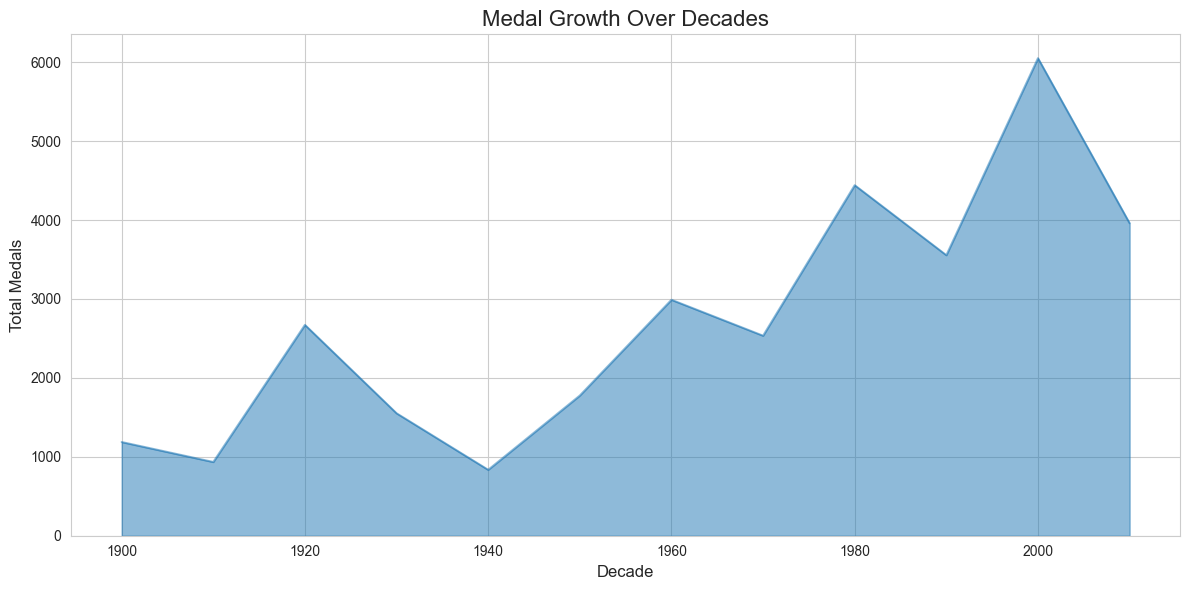

In [58]:
# =========================================================
# 18. MEDAL GROWTH OVER DECADES
# Area Chart
# =========================================================

# Dekade erstellen

df["decade"] = (

    (df["year"] // 10) * 10
)

medal_decades = (

    df[df["medal_win"] == 1]

    .groupby("decade")

    .size()
)

plt.figure(figsize=(12,6))

medal_decades.plot(

    kind="area",

    alpha=0.5
)

plt.title(

    "Medal Growth Over Decades",
    fontsize=16
)

plt.xlabel(

    "Decade",
    fontsize=12
)

plt.ylabel(

    "Total Medals",
    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()

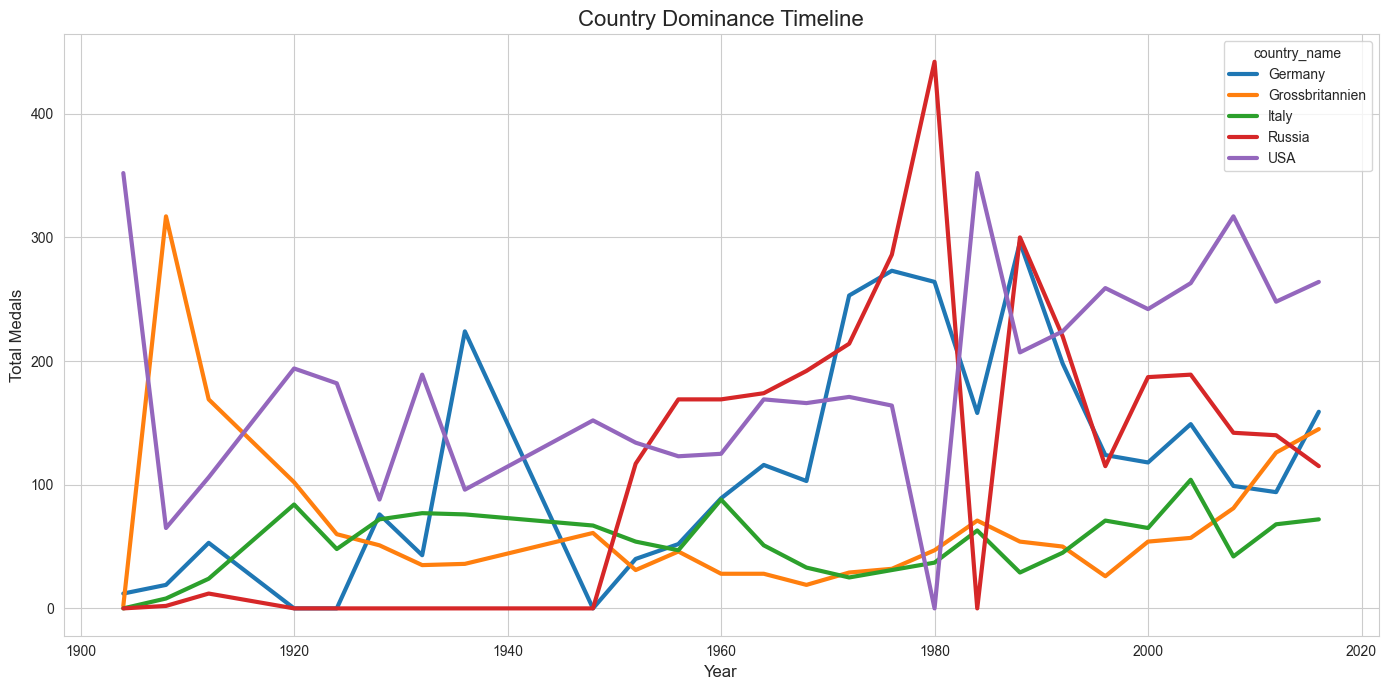

In [59]:
# =========================================================
# 19. COUNTRY DOMINANCE TIMELINE
# Ribbon Style Multi-Line Chart
# =========================================================

top5_countries = (

    df[df["medal_win"] == 1]

    .groupby("country_name")

    .size()

    .sort_values(ascending=False)

    .head(5)

    .index
)

timeline = (

    df[

        (df["country_name"].isin(top5_countries))

        &

        (df["medal_win"] == 1)
    ]

    .groupby([

        "year",

        "country_name"

    ])

    .size()

    .unstack(fill_value=0)
)

timeline.plot(

    figsize=(14,7),

    linewidth=3
)

plt.title(

    "Country Dominance Timeline",
    fontsize=16
)

plt.xlabel(

    "Year",
    fontsize=12
)

plt.ylabel(

    "Total Medals",
    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# =========================================================
# 20. VISUALISIERUNGEN SPEICHERN
# Optional für GitHub & Streamlit
# =========================================================

# Beispiel:
#
# plt.savefig(
#     "top_countries.png",
#     dpi=300,
#     bbox_inches="tight"
# )

In [60]:
# =========================================================
# 21. VISUALIZATION PROJEKT ABSCHLUSS
# =========================================================

print("\n=================================================")

print("ALLE OLYMPIC VISUALISIERUNGEN ERFOLGREICH ERSTELLT")

print("=================================================\n")

print("Visualisierungen erstellt:")
print("- Medals Over Time")
print("- Top 10 Countries")
print("- Participation Growth")
print("- Sports Distribution")
print("- Country Medal Ranking")
print("- Country vs Sport Heatmap")
print("- Medal Trend by Country")
print("- World Map")
print("- Average Age by Sport")
print("- Height vs Weight Analysis")
print("- Top Athletes")
print("- BMI Distribution")
print("- Medal Ratio by Gender")
print("- Participation by Gender Over Time")
print("- Average Age by Gender")
print("- Sport Participation by Gender")
print("- Athlete Age Evolution")
print("- Medal Growth Over Decades")
print("- Country Dominance Timeline")


ALLE OLYMPIC VISUALISIERUNGEN ERFOLGREICH ERSTELLT

Visualisierungen erstellt:
- Medals Over Time
- Top 10 Countries
- Participation Growth
- Sports Distribution
- Country Medal Ranking
- Country vs Sport Heatmap
- Medal Trend by Country
- World Map
- Average Age by Sport
- Height vs Weight Analysis
- Top Athletes
- BMI Distribution
- Medal Ratio by Gender
- Participation by Gender Over Time
- Average Age by Gender
- Sport Participation by Gender
- Athlete Age Evolution
- Medal Growth Over Decades
- Country Dominance Timeline
